# E03 - Filtros RC Passa-Alta e Passa-Baixa

Notebook de análise do Experimento 3 (FIS-46): resposta em frequência de filtros RC passa-alta (PA, saída sobre R) e passa-baixa (PB, saída sobre C), com R = 1,5 kΩ e C = 0,1 µF nominais.

Este notebook:
1. Transcreve e documenta a origem de cada leitura de Ve, Vs e defasagem a partir das capturas de tela do osciloscópio em `Images/` (ver também `dados_E03_transcritos.csv`, produzido nesta mesma etapa de transcrição).
2. Calcula ganho, ganho em dB e incertezas propagadas.
3. Calcula as curvas teóricas de ganho/fase e a frequência de corte, com incerteza propagada das tolerâncias de R e C.
4. Gera os gráficos (resposta linear, diagrama de Bode, resíduos) usados no relatório, salvos em `build/figs/`.
5. Recorta as capturas de tela usadas como figura ilustrativa no relatório, removendo o menu lateral (interface, não é dado) e o rodapé com data/modelo do aparelho, salvando em `build/figs/`.

**Convenção de incerteza de leitura**: as medidas de Ve, Vs e fase são leituras automáticas do osciloscópio (quadros "Pico a Pico"/"Amplitude" e "Fase:Ch1-Ch2"), não leituras manuais de régua/graticule. Na ausência de uma especificação de acurácia do fabricante à mão, adota-se a convenção usual de incerteza de leitura de mostrador digital: ±1 no último dígito significativo exibido (ex.: 4,99 V → ±0,01 V; 60,9° → ±0,1°). Essa suposição é declarada explicitamente no relatório.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw

ROOT = Path.cwd()
IMAGES = ROOT / "Images"
FIGS = ROOT / "build" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

## 1. Dados brutos transcritos das capturas de tela

Cada uma das 32 leituras (16 frequências × 2 filtros) foi obtida lendo diretamente o quadro de medidas sobreposto na tela do osciloscópio (`Pico a Pico` de Ch1 = Ve, `Pico a Pico` de Ch2 = Vs, `Fase:Ch1-Ch2` = defasagem), presente independente de qual menu lateral está aberto na captura. O arquivo `dados_E03_transcritos.csv` documenta, para cada ponto, o arquivo de origem e observações de conferência.

**Rotulagem incorreta encontrada e corrigida** (nome do arquivo não corresponde à frequência real, verificado pelo contador de frequência interno de cada imagem):
- `Amplitude_PA_1000hz_M.png` mostra contador de 599,997 Hz — na verdade é a medida de **600 Hz** (Fase=60,9°, Ve=4,99 V, Vs=2,43 V). Não existe arquivo `..._600hz_M.png` correto.
- `Amplitude_PA_1300hz_M.png` mostra contador de 999,99 Hz — na verdade é a medida de **1000 Hz** (Fase=46,6°, Ve=4,95 V, Vs=3,40 V). Não existe arquivo `..._1000hz_M.png` correto.
- `Amplitude_PA_10hz_M.png` é cópia duplicada (mesmo timestamp) de `Amplitude_PA_60hz_M.png` — não contém dado de 10 Hz; o ponto de 10 Hz genuíno vem de `Amplitudes_PA_10hz.png` (plural), cujo contador mostra `<10 Hz`.

**Lacunas reais de defasagem** (capturas sem o quadro "Fase:Ch1-Ch2" ativo, e sem nenhum arquivo alternativo — confirmado inclusive contra `Images/Alternative_Images/`, que é cópia idêntica por checksum): **PA em 800 Hz e 1300 Hz**. Nesses 2 pontos, a defasagem medida é ausente; usa-se o valor teórico da Eq. 1.4 apenas como estimativa de preenchimento, marcada explicitamente como não medida (ver Seção 3).

In [2]:
df = pd.read_csv(ROOT / "dados_E03_transcritos.csv")
df = df.sort_values(["filtro", "freq_hz"]).reset_index(drop=True)

# Incerteza de leitura: +-1 no ultimo digito significativo exibido no osciloscopio.
def last_digit_uncertainty(series, ndigits=2):
    return 10 ** (-ndigits)

df["sigma_Ve"] = 0.01  # V, valores de Ve tem 3 algarismos (ex. 4.99, 19.8)
df.loc[df["Ve_Vpp"] >= 10, "sigma_Ve"] = 0.1
df["sigma_Vs"] = 0.01
df.loc[df["Vs_Vpp"] >= 10, "sigma_Vs"] = 0.1
df.loc[df["Vs_Vpp"] < 1, "sigma_Vs"] = df.loc[df["Vs_Vpp"] < 1, "Vs_Vpp"].apply(
    lambda v: 10 ** (np.floor(np.log10(v)) - 2)
)
df["sigma_fase"] = 0.1  # grau, ultimo digito exibido (ex. 60.9, 86.8)

pa = df[df.filtro == "PA"].set_index("freq_hz")
pb = df[df.filtro == "PB"].set_index("freq_hz")
pa[["arquivo_fonte", "Ve_Vpp", "Vs_Vpp", "fase_graus"]]

,arquivo_fonte,Ve_Vpp,Vs_Vpp,fase_graus
freq_hz,,,,
10,Amplitudes_PA_10hz.png,4.11,0.0521,-86.80
30,Amplitude_PA_30hz_M.png,4.91,0.1500,93.00
60,Amplitude_PA_60hz_M.png,4.99,0.2900,86.80
100,Amplitude_PA_100hz_M.png,5.02,0.4710,85.20
300,Amplitude_PA_300hz_M.png,5.06,1.3700,74.70
600,Amplitude_PA_1000hz_M.png,4.99,2.4300,60.90
800,Amplitude_PA_800hz.png,19.20,11.6000,NaN
1000,Amplitude_PA_1300hz_M.png,4.95,3.4000,46.60
1300,Amplitude_PA_1300hz.png,19.20,14.6000,NaN


## 2. Ganho e incerteza propagada

$G = V_s/V_e$; incerteza por propagação usual (Vuolo, 1996):
$\sigma_G = G\sqrt{(\sigma_{V_s}/V_s)^2+(\sigma_{V_e}/V_e)^2}$.

$G_{dB} = 20\log_{10}G$; $\sigma_{G_{dB}} = \dfrac{20}{\ln 10}\cdot\dfrac{\sigma_G}{G}$.

In [3]:
def gain_and_uncertainty(d):
    G = d["Vs_Vpp"] / d["Ve_Vpp"]
    sigma_G = G * np.sqrt((d["sigma_Vs"] / d["Vs_Vpp"]) ** 2 + (d["sigma_Ve"] / d["Ve_Vpp"]) ** 2)
    G_dB = 20 * np.log10(G)
    sigma_GdB = (20 / np.log(10)) * (sigma_G / G)
    return G, sigma_G, G_dB, sigma_GdB

for d in (pa, pb):
    d["G"], d["sigma_G"], d["G_dB"], d["sigma_G_dB"] = gain_and_uncertainty(d)

pa[["Ve_Vpp", "Vs_Vpp", "G", "sigma_G", "G_dB", "sigma_G_dB", "fase_graus", "sigma_fase"]].round(4)

,Ve_Vpp,Vs_Vpp,G,sigma_G,G_dB,sigma_G_dB,fase_graus,sigma_fase
freq_hz,,,,,,,,
10,4.11,0.0521,0.0127,0.0000,-37.9401,0.0269,-86.80,0.1
30,4.91,0.1500,0.0305,0.0002,-30.2998,0.0605,93.00,0.1
60,4.99,0.2900,0.0581,0.0002,-24.7141,0.0346,86.80,0.1
100,5.02,0.4710,0.0938,0.0003,-20.5537,0.0253,85.20,0.1
300,5.06,1.3700,0.2708,0.0020,-11.3486,0.0657,74.70,0.1
600,4.99,2.4300,0.4870,0.0022,-6.2499,0.0398,60.90,0.1
800,19.20,11.6000,0.6042,0.0061,-4.3769,0.0875,NaN,0.1
1000,4.95,3.4000,0.6869,0.0025,-3.2625,0.0310,46.60,0.1
1300,19.20,14.6000,0.7604,0.0065,-2.3790,0.0747,NaN,0.1


## 3. Modelo teórico e frequência de corte

R = 1500 Ω ± 5% (filme, tolerância nominal típica assumida), C = 0,1 µF ± 10% (cerâmico, tolerância nominal típica assumida) — valores reais não medidos com multímetro nesta prática.

- Passa-alta: $G(f)=\dfrac{\omega RC}{\sqrt{1+(\omega RC)^2}}$, $\Phi(f)=\arctan\!\left(\dfrac{1}{\omega RC}\right)$ (Eqs. 1.3-1.4).
- Passa-baixa: $G(f)=\dfrac{1}{\sqrt{1+(\omega RC)^2}}$, $\Phi(f)=\arctan(\omega RC)$ (Eqs. 1.7-1.8), com sinal negativo (atraso) por convenção do roteiro.
- Frequência de corte: $f_c=1/(2\pi RC)$ (Eq. 1.10), com $\sigma_{f_c}=f_c\sqrt{(\sigma_R/R)^2+(\sigma_C/C)^2}$.

Os 2 pontos de PA sem defasagem medida (800 Hz e 1300 Hz) recebem a fase teórica calculada abaixo apenas como estimativa de preenchimento visual da curva — marcados com `fase_estimada=True` e excluídos do cálculo de resíduos de fase.

In [4]:
R = 1500.0
sigma_R = 0.05 * R
C = 0.1e-6
sigma_C = 0.10 * C

fc = 1 / (2 * np.pi * R * C)
sigma_fc = fc * np.sqrt((sigma_R / R) ** 2 + (sigma_C / C) ** 2)
print(f"f_c = {fc:.1f} +- {sigma_fc:.1f} Hz")

def G_teo_PA(f):
    wrc = 2 * np.pi * f * R * C
    return wrc / np.sqrt(1 + wrc ** 2)

def phi_teo_PA(f):
    wrc = 2 * np.pi * f * R * C
    return np.degrees(np.arctan(1 / wrc))

def G_teo_PB(f):
    wrc = 2 * np.pi * f * R * C
    return 1 / np.sqrt(1 + wrc ** 2)

def phi_teo_PB(f):
    wrc = 2 * np.pi * f * R * C
    return -np.degrees(np.arctan(wrc))

pa["fase_estimada"] = False
pa["fase_graus_completa"] = pa["fase_graus"]
for f_gap in (800, 1300):
    phi_est = phi_teo_PA(f_gap)
    pa.loc[f_gap, "fase_graus_completa"] = phi_est
    pa.loc[f_gap, "fase_estimada"] = True
    print(f"PA {f_gap} Hz: fase medida ausente -> estimativa teorica = {phi_est:.1f} graus")

pb["fase_estimada"] = False
pb["fase_graus_completa"] = pb["fase_graus"]

f_c = 1061.0 +- 118.6 Hz
PA 800 Hz: fase medida ausente -> estimativa teorica = 53.0 graus
PA 1300 Hz: fase medida ausente -> estimativa teorica = 39.2 graus


In [5]:
pa["G_teo"] = G_teo_PA(pa.index.values)
pa["phi_teo"] = phi_teo_PA(pa.index.values)
pb["G_teo"] = G_teo_PB(pb.index.values)
pb["phi_teo"] = phi_teo_PB(pb.index.values)

for d, name in ((pa, "PA"), (pb, "PB")):
    d["resid_G"] = d["G"] - d["G_teo"]
    d["resid_fase"] = np.where(d["fase_estimada"], np.nan, d["fase_graus_completa"] - d["phi_teo"])

print("Residuos de ganho (medido - teorico):")
print("PA:", pa["resid_G"].round(4).to_dict())
print("PB:", pb["resid_G"].round(4).to_dict())
print("\nResiduos de fase em graus (medido - teorico, NaN = ponto estimado, excluido):")
print("PA:", pa["resid_fase"].round(2).to_dict())
print("PB:", pb["resid_fase"].round(2).to_dict())

Residuos de ganho (medido - teorico):
PA: {10: 0.0033, 30: 0.0023, 60: 0.0017, 100: -0.0, 300: -0.0013, 600: -0.0053, 800: 0.0021, 1000: 0.001, 1300: -0.0143, 2000: -0.0109, 3000: -0.0029, 6000: -0.0028, 10000: -0.0096, 20000: -0.0037, 30000: -0.0095, 40000: 0.0055}
PB: {10: 0.0, 30: 0.0004, 60: 0.0016, 100: 0.0124, 300: 0.0057, 600: 0.0135, 800: -0.0037, 1000: 0.0121, 1300: 0.0093, 2000: 0.0083, 3000: 0.01, 6000: 0.0024, 10000: 0.0005, 20000: 0.0011, 30000: 0.0018, 40000: 0.0019}

Residuos de fase em graus (medido - teorico, NaN = ponto estimado, excluido):
PA: {10: -176.26, 30: 4.62, 60: 0.04, 100: 0.58, 300: 0.49, 600: 0.39, 800: nan, 1000: -0.1, 1300: nan, 2000: -0.55, 3000: 0.82, 6000: 0.27, 10000: 0.26, 20000: 0.42, 30000: 0.56, 40000: -0.15}
PB: {10: -0.18, 30: 0.76, 60: 0.43, 100: -1.09, 300: 0.29, 600: 1.19, 800: 0.92, 1000: 0.9, 1300: 0.78, 2000: 1.55, 3000: 2.12, 6000: 1.37, 10000: 0.74, 20000: 1.46, 30000: 2.47, 40000: 3.58}


## 4. Gráficos de resposta em frequência

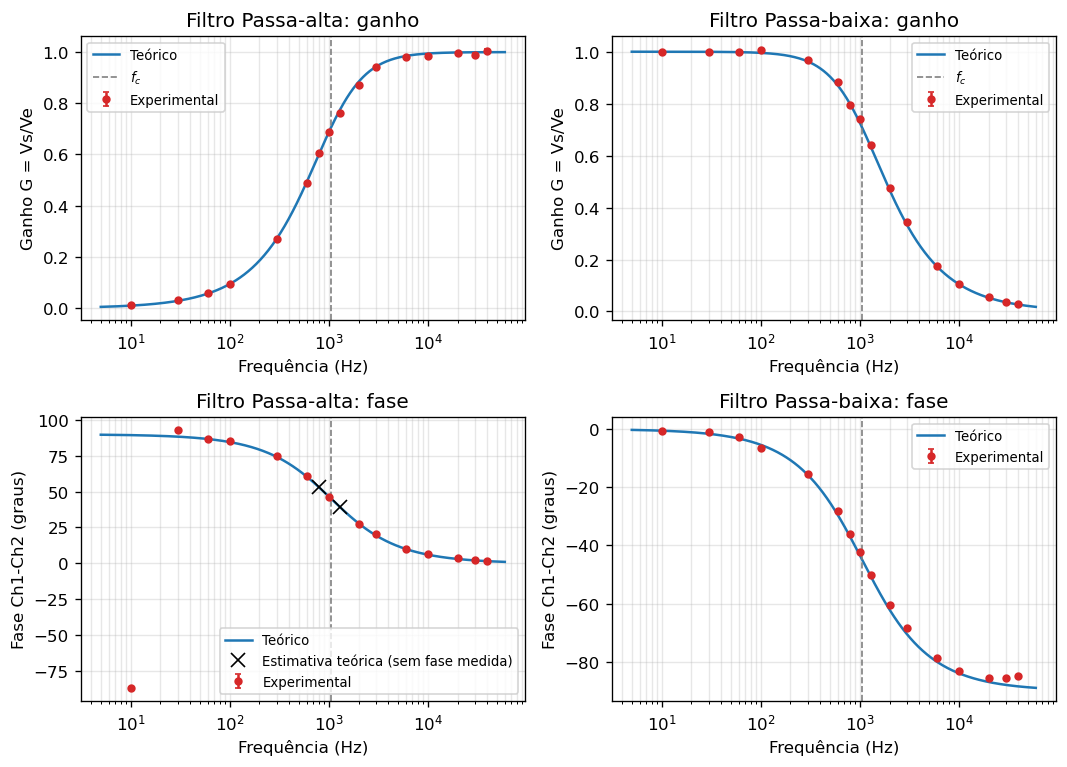

In [6]:
f_cont = np.logspace(np.log10(5), np.log10(60000), 500)

fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), sharex=False)

for ax, d, name in ((axes[0, 0], pa, "Passa-alta"), (axes[0, 1], pb, "Passa-baixa")):
    Gf = G_teo_PA(f_cont) if name == "Passa-alta" else G_teo_PB(f_cont)
    ax.plot(f_cont, Gf, "-", color="tab:blue", label="Teórico")
    ax.errorbar(d.index, d["G"], yerr=d["sigma_G"], fmt="o", ms=4, color="tab:red",
                capsize=2, label="Experimental")
    ax.axvline(fc, color="gray", ls="--", lw=1, label=r"$f_c$")
    ax.set_xscale("log")
    ax.set_xlabel("Frequência (Hz)")
    ax.set_ylabel("Ganho G = Vs/Ve")
    ax.set_title(f"Filtro {name}: ganho")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

for ax, d, name in ((axes[1, 0], pa, "Passa-alta"), (axes[1, 1], pb, "Passa-baixa")):
    Pf = phi_teo_PA(f_cont) if name == "Passa-alta" else phi_teo_PB(f_cont)
    ax.plot(f_cont, Pf, "-", color="tab:blue", label="Teórico")
    medidos = d[~d["fase_estimada"]]
    estimados = d[d["fase_estimada"]]
    ax.errorbar(medidos.index, medidos["fase_graus_completa"], yerr=medidos["sigma_fase"],
                fmt="o", ms=4, color="tab:red", capsize=2, label="Experimental")
    if len(estimados):
        ax.plot(estimados.index, estimados["fase_graus_completa"], "x", ms=8, color="black",
                label="Estimativa teórica (sem fase medida)")
    ax.axvline(fc, color="gray", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("Frequência (Hz)")
    ax.set_ylabel("Fase Ch1-Ch2 (graus)")
    ax.set_title(f"Filtro {name}: fase")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGS / "resposta_linear.pdf")
fig.savefig(FIGS / "resposta_linear.png")
plt.show()

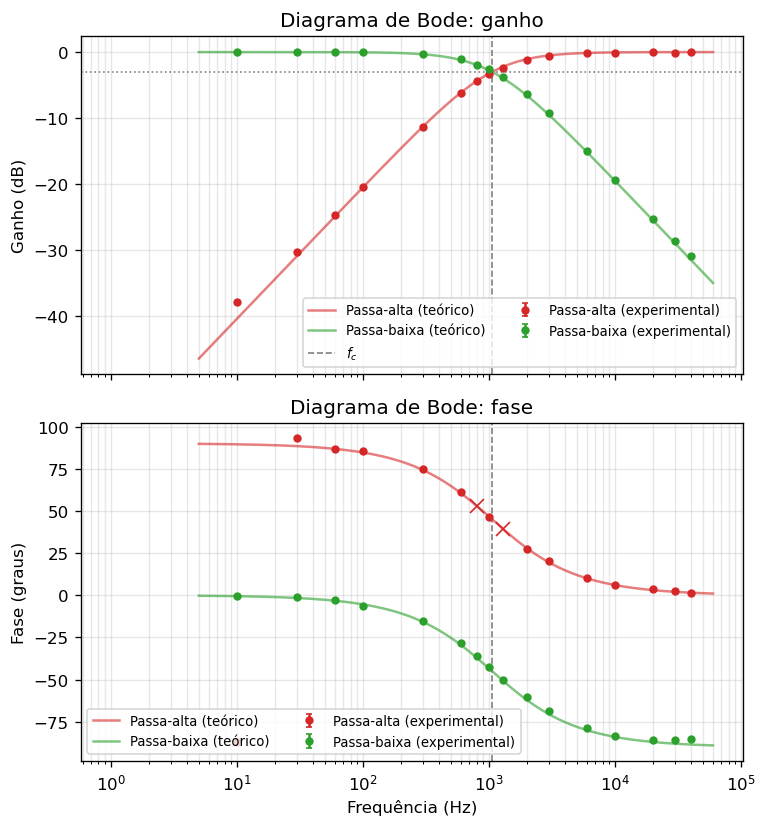

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(6.5, 7), sharex=True)

ax = axes[0]
for d, name, color in ((pa, "Passa-alta", "tab:red"), (pb, "Passa-baixa", "tab:green")):
    Gf_dB = 20 * np.log10(G_teo_PA(f_cont) if name == "Passa-alta" else G_teo_PB(f_cont))
    ax.plot(f_cont, Gf_dB, "-", color=color, alpha=0.6, label=f"{name} (teórico)")
    ax.errorbar(d.index, d["G_dB"], yerr=d["sigma_G_dB"], fmt="o", ms=4, color=color, capsize=2,
                label=f"{name} (experimental)")
ax.axvline(fc, color="gray", ls="--", lw=1, label=r"$f_c$")
ax.axhline(-3, color="gray", ls=":", lw=1)
ax.set_xscale("log")
ax.set_ylabel("Ganho (dB)")
ax.set_title("Diagrama de Bode: ganho")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for d, name, color in ((pa, "Passa-alta", "tab:red"), (pb, "Passa-baixa", "tab:green")):
    Pf = phi_teo_PA(f_cont) if name == "Passa-alta" else phi_teo_PB(f_cont)
    ax.plot(f_cont, Pf, "-", color=color, alpha=0.6, label=f"{name} (teórico)")
    medidos = d[~d["fase_estimada"]]
    estimados = d[d["fase_estimada"]]
    ax.errorbar(medidos.index, medidos["fase_graus_completa"], yerr=medidos["sigma_fase"],
                fmt="o", ms=4, color=color, capsize=2, label=f"{name} (experimental)")
    if len(estimados):
        ax.plot(estimados.index, estimados["fase_graus_completa"], "x", ms=8, color=color)
ax.axvline(fc, color="gray", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Frequência (Hz)")
ax.set_ylabel("Fase (graus)")
ax.set_title("Diagrama de Bode: fase")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
fig.savefig(FIGS / "bode.pdf")
fig.savefig(FIGS / "bode.png")
plt.show()

## 5. Análise de resíduos (medido − teórico)

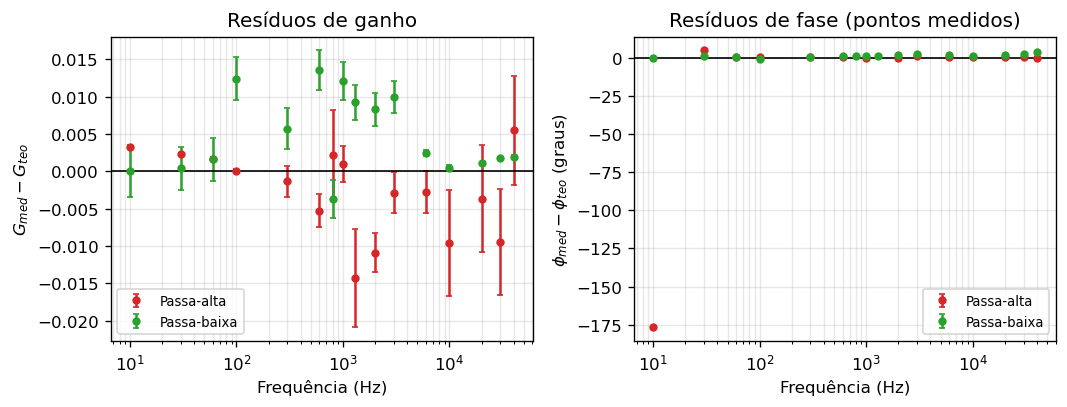

Resumo dos residuos de ganho:
  PA: media=-0.0028, desvio padrao=0.0057, max|resid|=0.0143
  PB: media=0.0048, desvio padrao=0.0053, max|resid|=0.0135

Resumo dos residuos de fase (graus, so pontos medidos):
  PA: media=-12.04, desvio padrao=47.28, max|resid|=176.26
  PB: media=1.08, desvio padrao=1.08, max|resid|=3.58


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

ax = axes[0]
for d, name, color in ((pa, "Passa-alta", "tab:red"), (pb, "Passa-baixa", "tab:green")):
    ax.errorbar(d.index, d["resid_G"], yerr=d["sigma_G"], fmt="o", ms=4, color=color,
                capsize=2, label=name)
ax.axhline(0, color="black", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Frequência (Hz)")
ax.set_ylabel(r"$G_{med}-G_{teo}$")
ax.set_title("Resíduos de ganho")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for d, name, color in ((pa, "Passa-alta", "tab:red"), (pb, "Passa-baixa", "tab:green")):
    medidos = d[~d["fase_estimada"]]
    ax.errorbar(medidos.index, medidos["resid_fase"], yerr=medidos["sigma_fase"], fmt="o", ms=4,
                color=color, capsize=2, label=name)
ax.axhline(0, color="black", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Frequência (Hz)")
ax.set_ylabel(r"$\phi_{med}-\phi_{teo}$ (graus)")
ax.set_title("Resíduos de fase (pontos medidos)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGS / "residuos.pdf")
fig.savefig(FIGS / "residuos.png")
plt.show()

print("Resumo dos residuos de ganho:")
for d, name in ((pa, "PA"), (pb, "PB")):
    print(f"  {name}: media={d['resid_G'].mean():.4f}, desvio padrao={d['resid_G'].std():.4f}, max|resid|={d['resid_G'].abs().max():.4f}")
print("\nResumo dos residuos de fase (graus, so pontos medidos):")
for d, name in ((pa, "PA"), (pb, "PB")):
    r = d.loc[~d["fase_estimada"], "resid_fase"]
    print(f"  {name}: media={r.mean():.2f}, desvio padrao={r.std():.2f}, max|resid|={r.abs().max():.2f}")

**Anomalia identificada em PA, 10 Hz**: o resíduo de fase nesse ponto é enorme (≈-176°) porque a fase medida tem sinal negativo (-86,8°), destoando da tendência positiva decrescente dos demais pontos de PA (93° a 1,4°) e do valor teórico (+89,5°). Em módulo, a concordância é boa (|−86,8|−89,5=−2,7°, dentro da tendência dos demais resíduos). A imagem de origem (`Amplitudes_PA_10hz.png`) mostra o traço de Ch2 visivelmente ruidoso/serrilhado, compatível com Vs muito pequeno (52 mV, próximo do piso de ruído do osciloscópio nessa escala) — nessas condições, o algoritmo automático de medida de fase do instrumento é suscetível a ambiguidade/inversão de sinal. Tratado como erro sistemático de medida nesse ponto específico, discutido no texto do relatório, e não removido/escondido da tabela.

## 6. Processamento das capturas de tela usadas como figura

Recorta a barra de menu lateral (interface do osciloscópio, não é dado) e o rodapé com data/modelo do aparelho, mantendo o graticule e a barra de leituras (V/div, tempo/div, frequência) e o quadro de medidas (Pico a Pico / Fase). Geometria (684×600 → sidebar em x∈[682,800], y∈[0,480]; rodapé abaixo de y=516) conferida visualmente numa imagem de amostra antes de aplicar em lote.

Painéis escolhidos para a figura ilustrativa do relatório: cada filtro em uma frequência bem abaixo de $f_c$≈1061 Hz, uma próxima de $f_c$ (1000 Hz) e uma bem acima, mostrando visualmente a transição de atenuação/passagem.

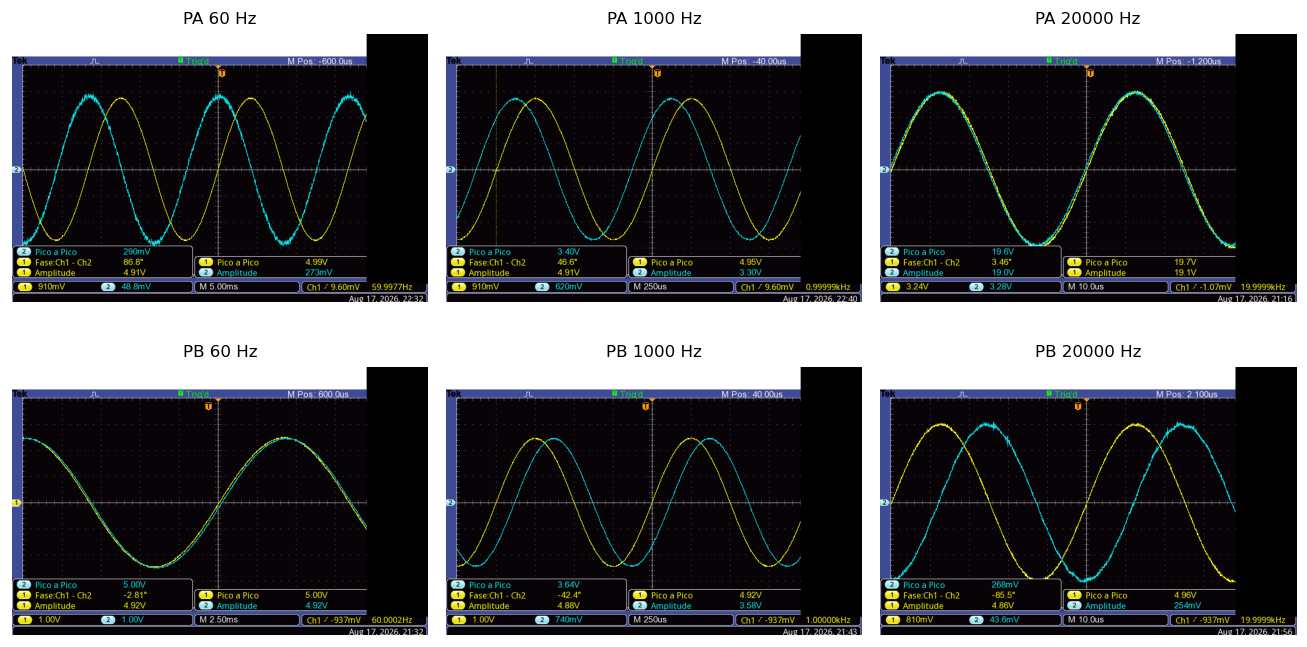

Figuras cortadas salvas em: /home/jonatas/Documentos/FUND/Fis46/build/figs
 - PA_60hz_cortada.png
 - PA_1000hz_cortada.png
 - PA_20000hz_cortada.png
 - PB_60hz_cortada.png
 - PB_1000hz_cortada.png
 - PB_20000hz_cortada.png


In [9]:
def crop_scope_screenshot(src_path, dst_path, sidebar_x0=682, sidebar_y1=480, footer_y=516):
    im = Image.open(src_path).convert("RGB")
    w, h = im.size
    draw = ImageDraw.Draw(im)
    draw.rectangle([sidebar_x0, 0, w, sidebar_y1], fill=(0, 0, 0))
    im = im.crop((0, 0, w, footer_y))
    im.save(dst_path)
    return im

panel_freqs = [60, 1000, 20000]
panels = []
for freq in panel_freqs:
    src = IMAGES / pa.loc[freq, "arquivo_fonte"]
    dst = FIGS / f"PA_{freq}hz_cortada.png"
    crop_scope_screenshot(src, dst)
    panels.append((f"PA {freq} Hz", dst))
for freq in panel_freqs:
    src = IMAGES / pb.loc[freq, "arquivo_fonte"]
    dst = FIGS / f"PB_{freq}hz_cortada.png"
    crop_scope_screenshot(src, dst)
    panels.append((f"PB {freq} Hz", dst))

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, (label, path) in zip(axes.flat, panels):
    ax.imshow(Image.open(path))
    ax.set_title(label, fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

print("Figuras cortadas salvas em:", FIGS)
for label, path in panels:
    print(" -", path.name)

## 7. Tabelas finais (dados brutos + grandezas calculadas) para o relatório

In [10]:
def format_row(freq, d):
    row = d.loc[freq]
    fase_txt = f"{row['fase_graus_completa']:.1f}" + ("$^\\dagger$" if row["fase_estimada"] else "")
    return (f"{freq:g} & {row['Ve_Vpp']:.2f} $\\pm$ {row['sigma_Ve']:.2f} & "
            f"{row['Vs_Vpp']:.3f} $\\pm$ {row['sigma_Vs']:.3f} & "
            f"{fase_txt} & {row['G']:.3f} $\\pm$ {row['sigma_G']:.3f} & "
            f"{row['G_dB']:.2f} $\\pm$ {row['sigma_G_dB']:.2f} \\\\")

print("% Tabela PA (passa-alta) - copiar linhas para o .tex")
for freq in pa.index:
    print(format_row(freq, pa))

print("\n% Tabela PB (passa-baixa) - copiar linhas para o .tex")
for freq in pb.index:
    print(format_row(freq, pb))

print(f"\nf_c experimental esperado (teorico) = {fc:.1f} +- {sigma_fc:.1f} Hz")
# f_c experimental: frequencia onde G_dB cruza -3 dB, por interpolacao linear em log(f).
# np.interp exige xp (G_dB) crescente: PA e crescente com f, PB e decrescente com f -> inverter so o PB.
for d, name in ((pa, "PA"), (pb, "PB")):
    idx = np.argsort(d.index.values)
    freqs_sorted = d.index.values[idx]
    gdb_sorted = d["G_dB"].values[idx]
    if name == "PB":
        gdb_sorted = gdb_sorted[::-1]
        freqs_sorted = freqs_sorted[::-1]
    fc_exp_log = np.interp(-3, gdb_sorted, np.log10(freqs_sorted))
    print(f"f_c experimental ({name}, interpolado em -3dB) ~= {10**fc_exp_log:.0f} Hz")

% Tabela PA (passa-alta) - copiar linhas para o .tex
10 & 4.11 $\pm$ 0.01 & 0.052 $\pm$ 0.000 & -86.8 & 0.013 $\pm$ 0.000 & -37.94 $\pm$ 0.03 \\
30 & 4.91 $\pm$ 0.01 & 0.150 $\pm$ 0.001 & 93.0 & 0.031 $\pm$ 0.000 & -30.30 $\pm$ 0.06 \\
60 & 4.99 $\pm$ 0.01 & 0.290 $\pm$ 0.001 & 86.8 & 0.058 $\pm$ 0.000 & -24.71 $\pm$ 0.03 \\
100 & 5.02 $\pm$ 0.01 & 0.471 $\pm$ 0.001 & 85.2 & 0.094 $\pm$ 0.000 & -20.55 $\pm$ 0.03 \\
300 & 5.06 $\pm$ 0.01 & 1.370 $\pm$ 0.010 & 74.7 & 0.271 $\pm$ 0.002 & -11.35 $\pm$ 0.07 \\
600 & 4.99 $\pm$ 0.01 & 2.430 $\pm$ 0.010 & 60.9 & 0.487 $\pm$ 0.002 & -6.25 $\pm$ 0.04 \\
800 & 19.20 $\pm$ 0.10 & 11.600 $\pm$ 0.100 & 53.0$^\dagger$ & 0.604 $\pm$ 0.006 & -4.38 $\pm$ 0.09 \\
1000 & 4.95 $\pm$ 0.01 & 3.400 $\pm$ 0.010 & 46.6 & 0.687 $\pm$ 0.002 & -3.26 $\pm$ 0.03 \\
1300 & 19.20 $\pm$ 0.10 & 14.600 $\pm$ 0.100 & 39.2$^\dagger$ & 0.760 $\pm$ 0.007 & -2.38 $\pm$ 0.07 \\
2000 & 5.02 $\pm$ 0.01 & 4.380 $\pm$ 0.010 & 27.4 & 0.873 $\pm$ 0.003 & -1.18 $\pm$ 0.03 \\
3000 & 